In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
from pathlib import Path

# Load dataset from the data folder
candidate_paths = [
    Path("data") / "Supabase_est_data.csv",
    Path("..") / "data" / "Supabase_est_data.csv"
]
csv_path = next((p for p in candidate_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError(
        "Could not find 'Supabase_est_data.csv' in data/. "
        "Put the file in repo_root/data/."
    )

df = pd.read_csv(csv_path)
print(f"Loaded rows: {len(df)}")
df.head()

Loaded rows: 527


,id,jira_issue_key,title,estimated_time_seconds,actual_time_seconds,diff_seconds,estimated_hours,actual_hours,diff_hours
0,5518,SHUL-22,Forms module popup,144000,1087200,943200,40.0,302.00,262.00
1,5783,ISAD-1,Sync products,7200,270000,262800,2.0,75.00,73.00
2,794,HULTP-97,Create new submission,57600,306900,249300,16.0,85.25,69.25
3,4319,SIG-536,[BE] Environment separation and performance,28800,270000,241200,8.0,75.00,67.00
4,3529,ACT-28,Header / Navbar,57600,259200,201600,16.0,72.00,56.00


In [3]:
# Data quality checks (wrong data, missing values, and suspicious records)
required_cols = ["estimated_time_seconds", "actual_time_seconds"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

quality_df = df[required_cols].copy()

# Coerce to numeric to catch non-numeric values from source systems
for col in required_cols:
    quality_df[col] = pd.to_numeric(quality_df[col], errors="coerce")

quality_report = pd.DataFrame({
    "missing_values": quality_df.isna().sum(),
    "non_positive_values": (quality_df <= 0).sum(),
})

duplicate_pairs = quality_df.duplicated().sum()
invalid_rows = (quality_df["estimated_time_seconds"] <= 0) | (quality_df["actual_time_seconds"] <= 0)
invalid_rows = invalid_rows | quality_df[required_cols].isna().any(axis=1)

print("Data quality report:")
display(quality_report)
print(f"Duplicate rows (est+actual pair): {duplicate_pairs}")
print(f"Invalid rows (missing/non-positive): {int(invalid_rows.sum())}")

# Keep only rows valid for modeling
model_df_valid = quality_df.loc[~invalid_rows].copy()
model_df_valid.head()

Data quality report:


,missing_values,non_positive_values
estimated_time_seconds,0,0
actual_time_seconds,0,174


Duplicate rows (est+actual pair): 298
Invalid rows (missing/non-positive): 174


,estimated_time_seconds,actual_time_seconds
0,144000,1087200
1,7200,270000
2,57600,306900
3,28800,270000
4,57600,259200


In [4]:
# Outlier analysis using IQR (robust for skewed time data)
q1_est, q3_est = model_df_valid["estimated_time_seconds"].quantile([0.25, 0.75])
q1_act, q3_act = model_df_valid["actual_time_seconds"].quantile([0.25, 0.75])

iqr_est = q3_est - q1_est
iqr_act = q3_act - q1_act

lower_est = q1_est - 1.5 * iqr_est
upper_est = q3_est + 1.5 * iqr_est
lower_act = q1_act - 1.5 * iqr_act
upper_act = q3_act + 1.5 * iqr_act

outlier_mask = (
    (model_df_valid["estimated_time_seconds"] < lower_est)
    | (model_df_valid["estimated_time_seconds"] > upper_est)
    | (model_df_valid["actual_time_seconds"] < lower_act)
    | (model_df_valid["actual_time_seconds"] > upper_act)
)

model_df_clean = model_df_valid.loc[~outlier_mask].copy()
model_df_outliers = model_df_valid.loc[outlier_mask].copy()

print(f"Valid rows before outlier filter: {len(model_df_valid)}")
print(f"Outliers detected: {int(outlier_mask.sum())}")
print(f"Rows after outlier filter: {len(model_df_clean)}")

# Prepare X/y for model training
X = model_df_clean[["estimated_time_seconds"]]
y = model_df_clean["actual_time_seconds"]

model_df_outliers.head()

Valid rows before outlier filter: 353
Outliers detected: 37
Rows after outlier filter: 316


,estimated_time_seconds,actual_time_seconds
0,144000,1087200
1,7200,270000
2,57600,306900
3,28800,270000
4,57600,259200


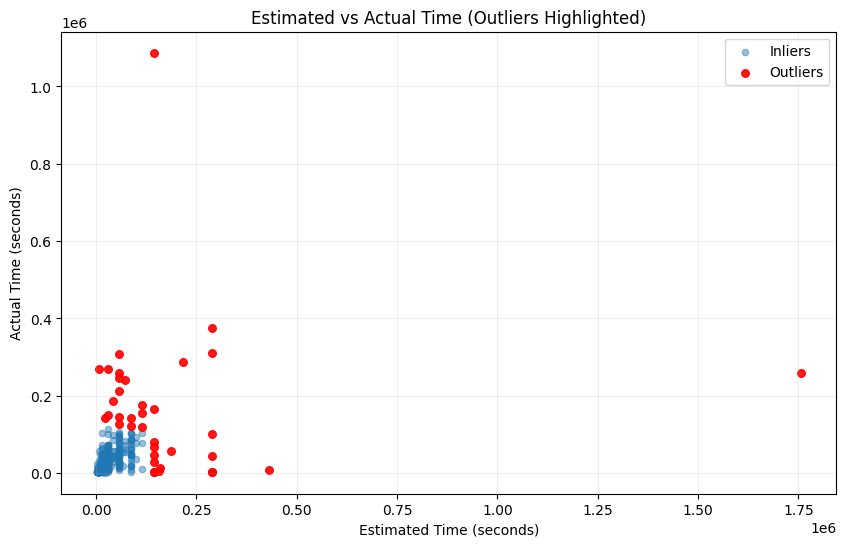

In [5]:
# Plot inliers vs outliers
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(
    model_df_clean["estimated_time_seconds"],
    model_df_clean["actual_time_seconds"],
    alpha=0.45,
    s=20,
    label="Inliers",
)

if len(model_df_outliers) > 0:
    plt.scatter(
        model_df_outliers["estimated_time_seconds"],
        model_df_outliers["actual_time_seconds"],
        alpha=0.9,
        s=30,
        color="red",
        label="Outliers",
    )

plt.title("Estimated vs Actual Time (Outliers Highlighted)")
plt.xlabel("Estimated Time (seconds)")
plt.ylabel("Actual Time (seconds)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [7]:
# Estimation confidence score based on historical error
n_boot = 2000
rng = np.random.default_rng(42)

# Compare original estimate vs actual on cleaned data
y_true = model_df_clean["actual_time_seconds"].to_numpy(dtype=float)
y_est = model_df_clean["estimated_time_seconds"].to_numpy(dtype=float)

abs_pct_error = np.abs(y_true - y_est) / y_true
mape = abs_pct_error.mean()

# Convert MAPE to an intuitive 0-100 confidence score (higher is better)
confidence_score = float(np.clip((1.0 - mape) * 100.0, 0.0, 100.0))

# Bootstrap CI for score stability
boot_mape = []
for _ in range(n_boot):
    idx = rng.integers(0, len(abs_pct_error), len(abs_pct_error))
    boot_mape.append(abs_pct_error[idx].mean())
boot_score = np.clip((1 - np.array(boot_mape)) * 100, 0, 100)
ci_low, ci_high = np.percentile(boot_score, [2.5, 97.5])

within_10 = (abs_pct_error <= 0.10).mean() * 100
within_20 = (abs_pct_error <= 0.20).mean() * 100
within_30 = (abs_pct_error <= 0.30).mean() * 100

print("Estimation quality summary")
print(f"Confidence score (MAPE-based): {confidence_score:.2f}/100")
print(f"95% CI for score: [{ci_low:.2f}, {ci_high:.2f}]")
print(f"Median absolute % error: {np.median(abs_pct_error) * 100:.2f}%")
print(f"Within +/-10%: {within_10:.2f}%")
print(f"Within +/-20%: {within_20:.2f}%")
print(f"Within +/-30%: {within_30:.2f}%")

Estimation quality summary
Confidence score (MAPE-based): 9.48/100
95% CI for score: [0.00, 30.84]
Median absolute % error: 39.94%
Within +/-10%: 22.78%
Within +/-20%: 33.54%
Within +/-30%: 38.29%


In [8]:
# Estimation bias: are we usually too high or too low?
bias_df = model_df_clean.copy()
bias_df["error_seconds"] = bias_df["estimated_time_seconds"] - bias_df["actual_time_seconds"]
bias_df["signed_pct_error"] = bias_df["error_seconds"] / bias_df["actual_time_seconds"]

too_high = (bias_df["error_seconds"] > 0).sum()
too_low = (bias_df["error_seconds"] < 0).sum()
exact = (bias_df["error_seconds"] == 0).sum()
n = len(bias_df)

pct_high = (too_high / n) * 100 if n else 0.0
pct_low = (too_low / n) * 100 if n else 0.0
pct_exact = (exact / n) * 100 if n else 0.0

mean_signed_pct = bias_df["signed_pct_error"].mean() * 100
median_signed_pct = bias_df["signed_pct_error"].median() * 100

direction = "too low" if mean_signed_pct < 0 else "too high"
print("Estimation bias summary")
print(f"Too high: {too_high} ({pct_high:.2f}%)")
print(f"Too low: {too_low} ({pct_low:.2f}%)")
print(f"Exact: {exact} ({pct_exact:.2f}%)")
print(f"Mean signed % error: {mean_signed_pct:.2f}%")
print(f"Median signed % error: {median_signed_pct:.2f}%")
print(f"Overall tendency: estimates are typically {direction}.")

Estimation bias summary
Too high: 139 (43.99%)
Too low: 121 (38.29%)
Exact: 56 (17.72%)
Mean signed % error: 57.49%
Median signed % error: 0.00%
Overall tendency: estimates are typically too high.


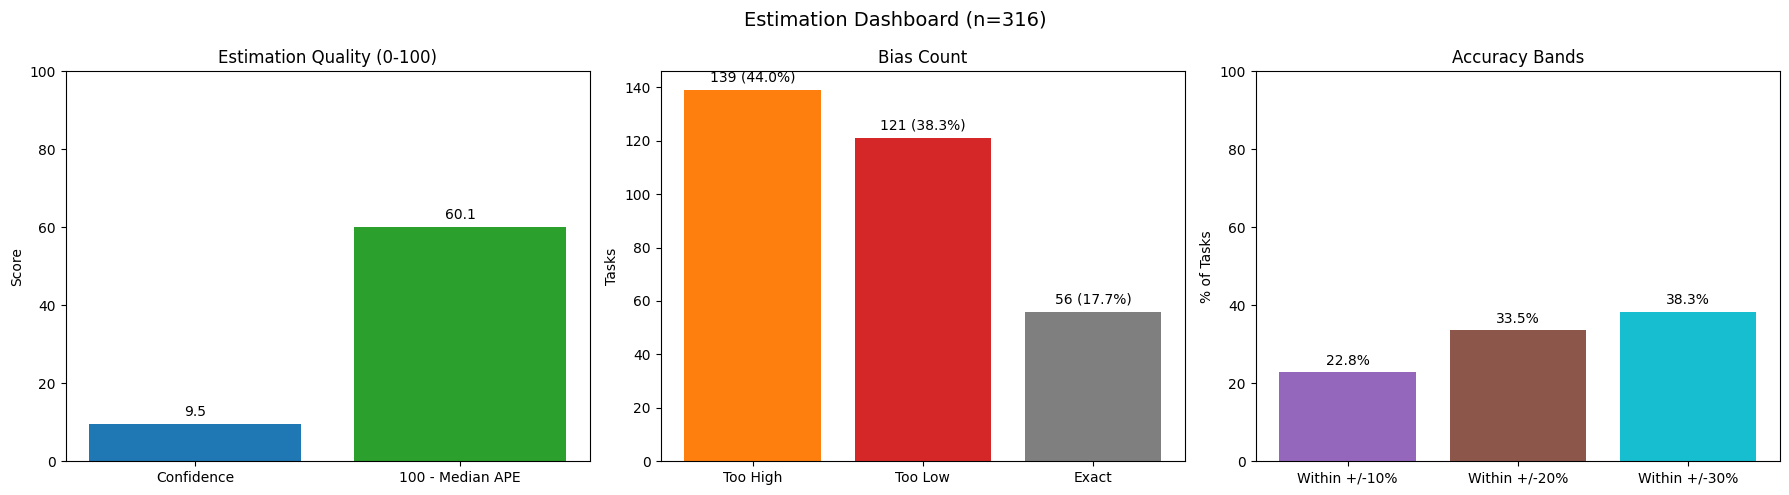

In [9]:
# Visual dashboard: estimation quality and bias
import matplotlib.pyplot as plt

viz_df = model_df_clean.copy()
viz_df["error_seconds"] = viz_df["estimated_time_seconds"] - viz_df["actual_time_seconds"]
viz_df["abs_pct_error"] = (viz_df["error_seconds"].abs() / viz_df["actual_time_seconds"]).clip(lower=0)
viz_df["signed_pct_error"] = viz_df["error_seconds"] / viz_df["actual_time_seconds"]

n = len(viz_df)
mape = viz_df["abs_pct_error"].mean()
confidence_score = float(np.clip((1.0 - mape) * 100.0, 0.0, 100.0))
median_ape = float(viz_df["abs_pct_error"].median() * 100)

too_high = int((viz_df["error_seconds"] > 0).sum())
too_low = int((viz_df["error_seconds"] < 0).sum())
exact = int((viz_df["error_seconds"] == 0).sum())

within_10 = float((viz_df["abs_pct_error"] <= 0.10).mean() * 100)
within_20 = float((viz_df["abs_pct_error"] <= 0.20).mean() * 100)
within_30 = float((viz_df["abs_pct_error"] <= 0.30).mean() * 100)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Quality overview
quality_labels = ["Confidence", "100 - Median APE"]
quality_vals = [confidence_score, max(0, 100 - median_ape)]
axes[0].bar(quality_labels, quality_vals, color=["#1f77b4", "#2ca02c"])
axes[0].set_ylim(0, 100)
axes[0].set_title("Estimation Quality (0-100)")
axes[0].set_ylabel("Score")
for i, v in enumerate(quality_vals):
    axes[0].text(i, v + 2, f"{v:.1f}", ha="center")

# 2) Bias split
bias_labels = ["Too High", "Too Low", "Exact"]
bias_vals = [too_high, too_low, exact]
axes[1].bar(bias_labels, bias_vals, color=["#ff7f0e", "#d62728", "#7f7f7f"])
axes[1].set_title("Bias Count")
axes[1].set_ylabel("Tasks")
for i, v in enumerate(bias_vals):
    pct = (v / n * 100) if n else 0
    axes[1].text(i, v + max(1, n * 0.01), f"{v} ({pct:.1f}%)", ha="center")

# 3) Accuracy bands
band_labels = ["Within +/-10%", "Within +/-20%", "Within +/-30%"]
band_vals = [within_10, within_20, within_30]
axes[2].bar(band_labels, band_vals, color=["#9467bd", "#8c564b", "#17becf"])
axes[2].set_ylim(0, 100)
axes[2].set_title("Accuracy Bands")
axes[2].set_ylabel("% of Tasks")
for i, v in enumerate(band_vals):
    axes[2].text(i, v + 2, f"{v:.1f}%", ha="center")

fig.suptitle(f"Estimation Dashboard (n={n})", fontsize=14)
fig.tight_layout()
plt.show()